# project: House price prediction
#Predict House Prices Using Linear Regression
# ============================================================
# 1. Problem Understanding

## Objective

The objective of this project is to build a Machine Learning model that predicts house prices based on different house features such as area, bedrooms, bathrooms, stories, parking, and other property characteristics.

## Problem Type

This is a **Supervised Machine Learning** problem specifically a **Regression** problem.


#import libraries

In [132]:
# Numerical Computing
import numpy as np
# Data Manipulation
import pandas as pd
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import joblib

#Load Dataset

In [133]:
df = pd.read_csv("Housing.csv")

#Data Exploration

In [134]:
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [135]:
df.shape

(545, 13)

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [137]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [138]:
df.isnull().sum() #number of missing values

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [139]:
df.duplicated().sum()

np.int64(0)

#Data Visualization

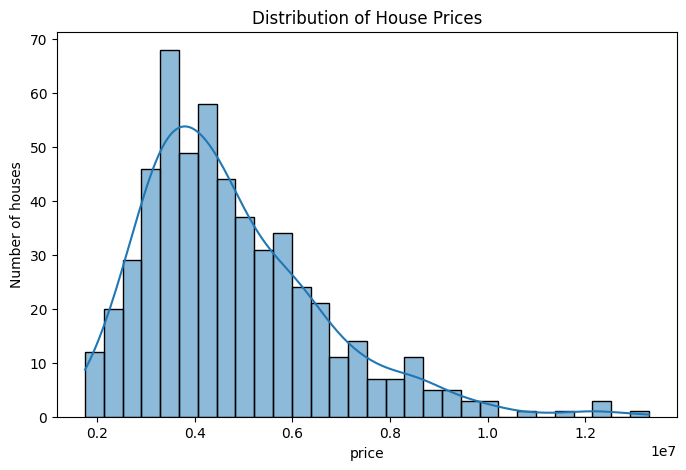

In [140]:
#Histogram
plt.figure(figsize=(8,5))
sns.histplot(
    df["price"],
    bins=30,kde=True,
    edgecolor="black"
    )
plt.title("Distribution of House Prices")
plt.xlabel("price")
plt.ylabel("Number of houses")
plt.show()


### Observation

- The target variable (price) is positively skewed.
- Most houses have prices between 3M and 6M.
- There are a few expensive houses with significantly higher prices.
- The distribution is not perfectly normal.

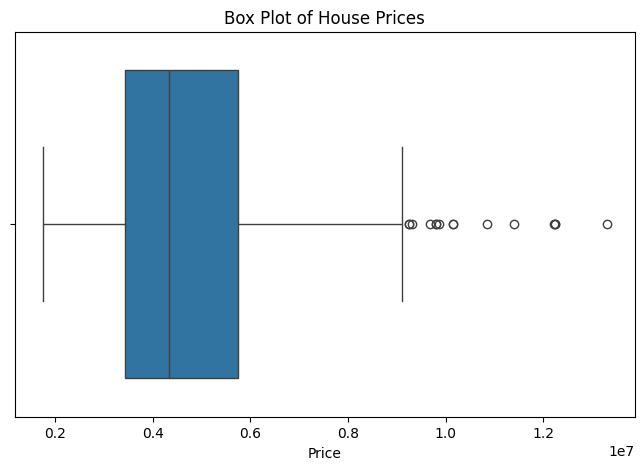

In [141]:
#Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Box Plot of House Prices")
plt.xlabel("Price")
plt.show()


### Observation

- The box plot shows several high-price outliers.
- Most outliers are on the higher price side.
- This agrees with the positively skewed distribution observed earlier.
- These values may represent luxury houses rather than data errors.

#=========================================================
#Correlation Matrix

In [142]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


In [143]:
correlation_matrix["price"].sort_values(ascending=False)

,price
price,1.000000
area,0.535997
bathrooms,0.517545
stories,0.420712
parking,0.384394
bedrooms,0.366494


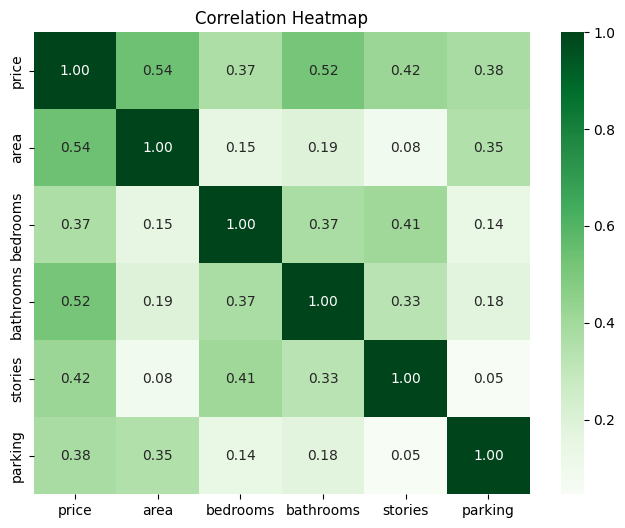

In [144]:
#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot= True,
    cmap="Greens",
     fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The correlation heatmap shows that **area** has the strongest positive correlation with house prices (**0.54**), making it the most influential numerical feature in the dataset.
- **Bathrooms (0.52)** and **stories (0.42)** also have moderate positive correlations with the target variable.
- **Bedrooms (0.37)** and **parking (0.38)** exhibit weaker positive relationships with house prices.
- None of the numerical features have a strong correlation (greater than **0.70**), indicating that house prices are influenced by multiple factors rather than a single feature.

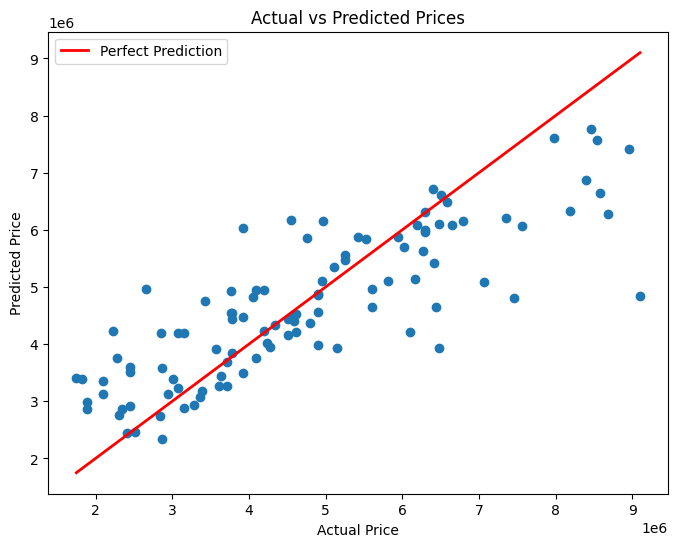

In [145]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.legend()
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

### Observation

The scatter plot compares the **actual** and **predicted** house prices. Most data points are clustered around the **perfect prediction line**, indicating that the Linear Regression model captures the overall relationship between the features and the target reasonably well. However, some points deviate from the line, especially for higher-priced houses, suggesting that the model struggles to accurately predict extreme values.

#Explore Categorical Features

In [146]:

categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [147]:
#Display Unique Values
for column in categorical_columns:
    print(f"{column}:")
    print(df[column].unique())
    print(""*40)

mainroad:
['yes' 'no']

guestroom:
['no' 'yes']

basement:
['no' 'yes']

hotwaterheating:
['no' 'yes']

airconditioning:
['yes' 'no']

prefarea:
['yes' 'no']

furnishingstatus:
['furnished' 'semi-furnished' 'unfurnished']



In [148]:
#Encode Binary Features
object_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for column in object_columns:
    df[column] = df[column].map({
        "yes": 1,
        "no": 0
    })

In [149]:
#One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True,
    dtype=int
)

In [150]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [151]:
#Remove outliers
Q1 = df["price"].quantile(0.25)

Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

df = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]

print(df.shape)

(530, 14)


In [152]:
#split Features and Target
X=df.drop("price",axis=1)
y=df["price"]
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [153]:
#Check Dataset Shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (424, 13)
X_test shape : (106, 13)
y_train shape: (424,)
y_test shape : (106,)


#Model Training

In [154]:
model = LinearRegression() #Create the Model
model.fit(X_train, y_train) #Train the Model



LinearRegression()

#Model Testing

In [155]:
y_pred = model.predict(X_test) #Predict House Prices

#Compare Actual vs Predicted
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
155,5530000,5.832190e+06
413,3430000,4.746658e+06
21,8680000,6.274860e+06
349,3780000,3.852171e+06
337,3920000,4.474905e+06
97,6300000,5.968058e+06
240,4585000,4.408556e+06
511,2520000,2.462304e+06
538,1890000,2.860865e+06
116,6020000,5.703782e+06


# Model Evaluation

In [156]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R² Score : {r2:.4f} ")

MAE  : 784877.26
MSE  : 1148203524699.74
RMSE : 1071542.59
R² Score : 0.6684 


# Save Model

In [157]:
joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [158]:
from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>